In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
%pip install -q nest_asyncio
%pip install -q "unstructured[md] nltk"

In [6]:
from langchain_community.document_loaders import PyPDFLoader
from pyzerox import zerox
import asyncio
import nest_asyncio
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import UnstructuredMarkdownLoader
import markdown
from bs4 import BeautifulSoup
from langchain_community.document_loaders import TextLoader

nest_asyncio.apply()

pdf_file_path = "./estate_tax.pdf"
loader = PyPDFLoader(pdf_file_path)
pages = []
async for page in loader.alazy_load():
    pages.append(page)


### Model Setup (Use only Vision Models) Refer: https://docs.litellm.ai/docs/providers ###

## placeholder for additional model kwargs which might be required for some models
kwargs = {}

## system prompt to use for the vision model
custom_system_prompt = None

# to override
# custom_system_prompt = "For the below PDF page, do something..something..." ## example

###################### Example for OpenAI ######################
model = "gpt-4o-mini" ## openai model

###################### For other providers refer: https://docs.litellm.ai/docs/providers ######################

# Define main async entrypoint
async def main():
    file_path = "./estate_tax.pdf" ## local filepath and file URL supported

    ## process only some pages or all
    select_pages = None ## None for all, but could be int or list(int) page numbers (1 indexed)

    output_dir = "./documents" ## directory to save the consolidated markdown file
    result = await zerox(file_path=file_path, model=model, output_dir=output_dir,
                        custom_system_prompt=custom_system_prompt,select_pages=select_pages, **kwargs)
    return result


# run the main function:
result = asyncio.run(main())

# print markdown result
print(result)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 100,
    separators =['\n\n', '\n']
)


markdown_path = "./documents/estate_tax.md"
loader = UnstructuredMarkdownLoader(markdown_path)

document_list = loader.load_and_split(text_splitter)

document_list[3]

text_path = './documents/estate_tax.txt'
with open(markdown_path, 'r', encoding = 'utf-8') as md_file:
    md_content = md_file.read()

html_content = markdown.markdown(md_content)

soup = BeautifulSoup(html_content, 'html.parser')
text_content = soup.get_text()

with open(text_path, 'w', encoding='utf-8') as txt_file:
    txt_file.write(text_content)

print("Markdown converted to plain text successfully!")

loader = TextLoader(text_path)
document_list = loader.load_and_split(text_splitter)
document_list[3]

ZeroxOutput(completion_time=21906.055, file_name='estate_tax', input_tokens=368770, output_tokens=10900, pages=[Page(content='# 종합부동산세법\n[시행 2026. 1. 1.][법률 제212244호, 2025. 12. 23., 일부개정]  \n재정경제부(재산세제과) 044-215-4313\n\n## 제1장 총칙\n\n### 제1조(목적)\n이 법은 고액의 부동산 보유자에 대해 종합부동산세를 부과하여 부동산보유에 대한 조세부담의 형평성을 제고하고, 부동산 가격안정을 도모함으로써 지방재정의 균형발전과 국민경제의 건전한 발전에 이바지함을 목적으로 한다.\n\n### 제2조(정의)\n이 법에서 사용하는 용어의 정의는 다음과 같다. <개정 2005. 12. 31., 2010. 3. 31., 2016. 1. 19., 2018. 12. 31., 2020. 6. 9., 2023. 3. 14.>\n\n1. "시", "군", "구"란 함은 「지방자치법」 제2조에 따른 지방자치단체의 시·군 및 자치구(이하 "시·군·구"라 한다)를 말한다.\n\n2. "주택"이란 함은 「주택법」 제104조제3항에 의한 주택을 말한다.\n\n3. "토지"란 함은 「지방세법」 제100조에 따른 토지를 말한다.\n\n4. "주택 종류"란 함은 「주택법」 제105조 및 제107조에 따라 주택에 부과하는 재산세를 말한다.\n\n5. "토지 종류"란 함은 「지방세법」 제105조 및 제107조에 따라 토지에 부과하는 재산세를 말한다.\n\n6. "세대"란 함은 주택 또는 토지의 소유자 및 배우자와 그들의 생계를 같이하는 가족으로서 정의하는 것을 말한다.\n\n7. "공시지가"란 함은 「부동산 가격공시 등에 관한 법률」에 따라 가격이 공시되는 주택 및 토지에 대한 같은 법에 따라 공시된 자산의 가액을 말한다. 단, 같은 법에 따라 공시되지 아니하는 경우에는 「지방세법」 제45조 단서 및 공시지가 표에 따라 가액으로

Document(metadata={'source': './documents/estate_tax.txt'}, page_content='제1호의 주택외에 종업원이 주거에 제공하기 위한 기숙사 및 사용임 주택, 주택건설사업자가 건축하여 소유하고 있는 미반양특 주택, 개정이란이 있는 주택, "수도정비기본법", 제203제1호에 해당 수도권 및 지역에 소속되는 1주택 중 종합부동산세를 부과할 목적으로 적합하지 아니한 것으로 정하는 주택, 그 경우 수도권의 지역에 소재하는 1주택의 경우는 2009년 1월 1일부터 2011년 12월 31일까지 기간 중 남세미주택으로 성립한 분에 한정한다.\n③ 제정안의 규정에 따른 주택을 보유한 남세미무자는 해당 연도 9월 30일까지 대통령에게 정하는 바에 따라 해당 세지 관할세무서장(이하 "관할세무서장"이라 한다)에 해당 주택의 보유현황을 신고하여 한다.https://law.go.kr 2007. 1. 11., 2020. 6. 9.\n\n제1항을 적용할 때 다음 각 호의 어느 하나에 해당하는 경우에는 1세대 1주택자로 본다.<개정 2022. 9. 15.>\n1. 주택(주택의 부족지분을 포함하는 경우는 제외한다)과 다른 주택의 부속토지를 소유하고가 다른 경우의 그 부속토지를 명한다고 함께 소유하고 있는 경우\n2. 1세대가 1주택을 양도하기 전에 다른 주택을 대체취득하여 일시적으로 된 경우로서 대통령으로 정하는 경우\n1. 주택과 상속받은 주택으로 대통령령으로 정하는 주택(이하 "상속주택"이라 한다)을 함께 소유하고 있는 경우\n4. 1주택과 주택 수도 지역, 주택 가용 등을 고려하여 대통령령으로 정하는 지방 저가주택(이하 "지방 저가주택"이라 한다)을 함께 소유하고 있는 경우\n⑥ 제3절제조문부터 제4호까지의 규정은 적용받는 것은 남세미무자는 해당 당 9월 16일부터 9월 30일까지 대통령으로 정하는 바에 따라 관할세무서장에게 신청하여 한다.<원성 2022. 9. 15.> 2008. 12. 26. 별별 규정제273조에 의하여 2008. 11

In [7]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str # 사용자 질문
    answer: str # 세율
    tax_base_equation: str # 과세표준 계산 수식
    tax_deduction: str # 공제액
    market_ratio: str # 공정시장가액비율
    tax_base: str # 과세표준 계산

graph_builder = StateGraph(AgentState)

In [9]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma.from_documents(
    documents=document_list,
    embedding=embedding,
    collection_name = 'estate_tasx_collection',
    persist_directory = './estate_tax_collection'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [10]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'

In [20]:
from langchain_openai import ChatOpenAI
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

rag_prompt = hub.pull('rlm/rag-prompt')
llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

/home/swjeong/langchain/langgraph/.venv/lib/python3.13/site-packages/langsmith/client.py:256: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [23]:
tax_base_equation_prompt = ChatPromptTemplate.from_messages([
    ('system', '사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요 부연설명 없이  수식만 리턴해주세요'),
    ('human', '{tax_base_equation_information}')
])

tax_base_retrieval_chain = {'context': retriever, 'question': RunnablePassthrough()} | rag_prompt | llm | StrOutputParser()

tax_base_equation_chain = {'tax_base_equation_information': RunnablePassthrough()} | tax_base_equation_prompt | llm | StrOutputParser()

tax_base_chain = {'tax_base_equation_information': tax_base_retrieval_chain} | tax_base_equation_chain

def get_tax_base_equation(state: AgentState) -> str:
    tax_base_equation_question = '주택에 대한 종합부동산세 계산 시 과세 표준을 계산하는 방법을 알려주세요'
    tax_base_equation = tax_base_chain.invoke(tax_base_equation_question)
    return {'tax_base_equation': tax_base_equation}

In [24]:
get_tax_base_equation({})

{'tax_base_equation': '과세표준 = (공시가격 - 공제금액) × 적용비율'}

In [29]:
tax_deduction_chain = {'context': retriever, 'question': RunnablePassthrough()} | rag_prompt | llm | StrOutputParser()

def get_tax_deduction(state: AgentState):
    tax_deduction_question = '주택에 대한 종합부동산세 계산시 공제금액을 알려주세요'
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)
    return {'tax_deduction': tax_deduction}

In [30]:
get_tax_deduction({})

{'tax_deduction': '주택에 대한 종합부동산세 계산 시 1세대 1주택자의 경우, 공제금액은 주택의 공시가격에 따라 다르며, 기본적으로 12억 원까지 공제됩니다. 만약 다른 기준에 해당한다면 공제금액은 달라질 수 있습니다.'}

In [35]:
from langchain_community.tools import TavilySearchResults
from datetime import date

tavily_search_tool = TavilySearchResults(
    max_results=3,
    search_depth='advanced',
    include_answer=True,
    include_raw_content=True,
    include_images=True
)

tax_market_ratio_prompt = ChatPromptTemplate.from_messages([
    ('system', f'아래 정보를 기반으로 오늘 날짜: ({date.today()})에 해당하는 공정시장 가액비율을 개산해주세요사용자의 질문에 답변해주세요\n\nContext:\n{{context}}'),
    ('human', '{query}')
])

def get_market_ratio(state: AgentState):
    query = '주택 공시가격 공정시장가액비율은 몇%인가요?'
    context = tavily_search_tool.invoke(query)
    tax_market_ratio_chain = tax_market_ratio_prompt | llm | StrOutputParser()
    market_ratio = tax_market_ratio_chain.invoke({'context': context, 'query': query})
    return {'market_ratio': market_ratio}

In [37]:
get_market_ratio({})

{'market_ratio': '2026년 7월 2일 기준으로 주택의 공정시장가액비율은 60%입니다.'}

In [49]:
from langchain_core.prompts import PromptTemplate

tax_base_calculation_prompt = ChatPromptTemplate.from_messages([
    ('system', """
    주어진 내용을 기반으로 과세표준을 계산해주세요

    과세표준 계산 공식: {tax_base_question}
    공제금액: {tax_deduction}
    공정시장가액비율: {market_ratio}
    """),
    ('human','사용자 주택 공시가격 정보: {query}')
])

def calculate_tax_base(state:AgentState):
    tax_base_question = state['tax_base_equation']
    tax_deduction = state['tax_deduction']
    market_ratio = state['market_ratio']
    query = state['query']
    tax_base_calculation_chain = tax_base_calculation_prompt | llm | StrOutputParser()
    tax_base = tax_base_calculation_chain.invoke({
        'tax_base_question': tax_base_question,
        'tax_deduction': tax_deduction,
        'market_ratio': market_ratio,
        'query': query
    })
    print(f'tax_base == {tax_base}')
    return {'tax_base': tax_base}

In [50]:
initial_state = ({
    'query': query,
    'tax_base_equation':'과세표준 = (주택 공시가격 합산 - 공제금액) * 공정시장가액비율',
    'tax_deduction': '주택에 대한 종합부동산세 계산 시 1세대 1주택자의 경우, 공제금액은 주택의 공시가격에 따라 다르며, 기본적으로 12억 원까지 공제됩니다. 만약 다른 기준에 해당한다면 공제금액은 달라질 수 있습니다.',
    'market_ratio': '2026년 7월 2일 기준으로 주택의 공정시장가액비율은 60%입니다.'
})

In [51]:
calculate_tax_base(initial_state)

tax_base == 주어진 정보에 따라 과세표준을 계산해보겠습니다.

1. 주택 공시가격 합산: 
   - 5억짜리 집 1채 + 10억짜리 집 1채 + 20억짜리 집 1채 = 35억 원

2. 공제금액: 
   - 1세대 1주택자가 아닌 경우 기본 공제금액은 적용되지 않습니다.

3. 공정시장가액비율:
   - 60% (2026년 7월 2일 기준)

따라서, 과세표준은 다음과 같이 계산됩니다:

과세표준 = (주택 공시가격 합산 - 공제금액) * 공정시장가액비율
과세표준 = (35억 원 - 0원) * 60%
과세표준 = 35억 원 * 0.6 = 21억 원

결과적으로, 과세표준은 21억 원입니다. 이 과세표준을 바탕으로 실제 세금액은 세율을 적용하여 계산될 것입니다. 세율은 과세표준에 따라 다르므로, 구체적인 세율 정보를 확인하여야 정확한 세금액을 계산할 수 있습니다.


{'tax_base': '주어진 정보에 따라 과세표준을 계산해보겠습니다.\n\n1. 주택 공시가격 합산: \n   - 5억짜리 집 1채 + 10억짜리 집 1채 + 20억짜리 집 1채 = 35억 원\n\n2. 공제금액: \n   - 1세대 1주택자가 아닌 경우 기본 공제금액은 적용되지 않습니다.\n\n3. 공정시장가액비율:\n   - 60% (2026년 7월 2일 기준)\n\n따라서, 과세표준은 다음과 같이 계산됩니다:\n\n과세표준 = (주택 공시가격 합산 - 공제금액) * 공정시장가액비율\n과세표준 = (35억 원 - 0원) * 60%\n과세표준 = 35억 원 * 0.6 = 21억 원\n\n결과적으로, 과세표준은 21억 원입니다. 이 과세표준을 바탕으로 실제 세금액은 세율을 적용하여 계산될 것입니다. 세율은 과세표준에 따라 다르므로, 구체적인 세율 정보를 확인하여야 정확한 세금액을 계산할 수 있습니다.'}

In [56]:
tax_rate_calculation_prompt = ChatPromptTemplate.from_messages([
    ('system', ''' 당신은 종합 부동산세 계산 전문가입니다. 아래 문서를 참고해서 사용자의 질문에 대한 종합부동산세를 계산해주세요
    종합 부동산세 세율: {context}'''),
    ('human', '''과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해주세요
    과세표준: {tax_base}
    {query}''')
])

def calculate_tax_rate(state: AgentState):
    query = state['query']
    tax_base = state['tax_base']
    context = retriever.invoke(query)
    tax_rate_chain = tax_rate_calculation_prompt | llm | StrOutputParser()

    tax_rate = tax_rate_chain.invoke({'context': context, 'tax_base': tax_base, 'query': query})
    print(f'tax_rate == {tax_rate}')
    return {'answer': tax_rate}

In [52]:
tax_base_state = {'tax_base': '주어진 정보에 따라 과세표준을 계산해보겠습니다.\n\n1. 주택 공시가격 합산: \n   - 5억짜리 집 1채 + 10억짜리 집 1채 + 20억짜리 집 1채 = 35억 원\n\n2. 공제금액: \n   - 1세대 1주택자가 아닌 경우 기본 공제금액은 적용되지 않습니다.\n\n3. 공정시장가액비율:\n   - 60% (2026년 7월 2일 기준)\n\n따라서, 과세표준은 다음과 같이 계산됩니다:\n\n과세표준 = (주택 공시가격 합산 - 공제금액) * 공정시장가액비율\n과세표준 = (35억 원 - 0원) * 60%\n과세표준 = 35억 원 * 0.6 = 21억 원\n\n결과적으로, 과세표준은 21억 원입니다. 이 과세표준을 바탕으로 실제 세금액은 세율을 적용하여 계산될 것입니다. 세율은 과세표준에 따라 다르므로, 구체적인 세율 정보를 확인하여야 정확한 세금액을 계산할 수 있습니다.', 'query': query}


In [57]:
calculate_tax_rate(tax_base_state)

tax_rate == 주어진 정보를 바탕으로 사용자가 3채의 주택을 소유하고 있으며, 과세표준은 21억 원으로 계산되었습니다. 이제 과세표준에 따른 종합부동산세를 계산해보겠습니다. 

먼저, 3주택 이상 소유자의 경우 과세표준에 따른 세율은 다음과 같습니다:

- 3억 원 이하: 12년분의 5
- 3억 원 초과 6억 원 이하: 150만 원 + (초과분의 1년분의 7)
- 6억 원 초과 12억 원 이하: 360만 원 + (초과분의 1년분의 10)
- 12억 원 초과 50억 원 이하: 960만 원 + (초과분의 1년분의 13)

과세표준이 21억 원이므로, 해당 세율 구간은 "12억 원 초과 50억 원 이하"입니다. 따라서, 세금은 다음과 같이 계산됩니다:

1. 기본 세액: 960만 원
2. 초과분: 21억 원 - 12억 원 = 9억 원
3. 초과분에 대한 세액: 9억 원 * (1년분의 13) = 6,923,077원

총 세금액 = 기본 세액 + 초과분 세액
총 세금액 = 960만 원 + 6,923,077원 = 1,652만 3,077원

따라서, 사용자는 1,652만 3,077원의 종합부동산세를 납부해야 합니다.


{'answer': '주어진 정보를 바탕으로 사용자가 3채의 주택을 소유하고 있으며, 과세표준은 21억 원으로 계산되었습니다. 이제 과세표준에 따른 종합부동산세를 계산해보겠습니다. \n\n먼저, 3주택 이상 소유자의 경우 과세표준에 따른 세율은 다음과 같습니다:\n\n- 3억 원 이하: 12년분의 5\n- 3억 원 초과 6억 원 이하: 150만 원 + (초과분의 1년분의 7)\n- 6억 원 초과 12억 원 이하: 360만 원 + (초과분의 1년분의 10)\n- 12억 원 초과 50억 원 이하: 960만 원 + (초과분의 1년분의 13)\n\n과세표준이 21억 원이므로, 해당 세율 구간은 "12억 원 초과 50억 원 이하"입니다. 따라서, 세금은 다음과 같이 계산됩니다:\n\n1. 기본 세액: 960만 원\n2. 초과분: 21억 원 - 12억 원 = 9억 원\n3. 초과분에 대한 세액: 9억 원 * (1년분의 13) = 6,923,077원\n\n총 세금액 = 기본 세액 + 초과분 세액\n총 세금액 = 960만 원 + 6,923,077원 = 1,652만 3,077원\n\n따라서, 사용자는 1,652만 3,077원의 종합부동산세를 납부해야 합니다.'}

In [58]:
graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('get_market_ratio', get_market_ratio)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax_rate', calculate_tax_rate)

In [59]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'get_tax_base_equation')
graph_builder.add_edge(START, 'get_tax_deduction')
graph_builder.add_edge(START, 'get_market_ratio')
graph_builder.add_edge('get_tax_base_equation','calculate_tax_base')
graph_builder.add_edge('get_tax_deduction','calculate_tax_base')
graph_builder.add_edge('get_market_ratio','calculate_tax_base')
graph_builder.add_edge('calculate_tax_base', 'calculate_tax_rate')
graph_builder.add_edge('calculate_tax_rate', END)

In [60]:
graph = graph_builder.compile()

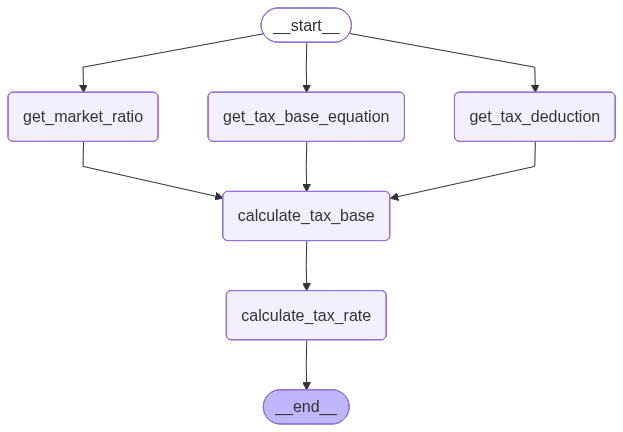

In [61]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = {'query': query}
graph.invoke(initial_state)

tax_base == 주어진 사용자 주택 공시가격 정보를 기반으로 각 주택의 과세표준을 계산하고 종합부동산세를 계산하겠습니다.

1. 5억짜리 집 (공시가격: 5억 원)
   - 공제금액: 12억 원 (1세대 1주택자 기준)
   - 공정시장가액비율: 44% (3억 초과 ~ 6억 이하)
   - 과세표준 = (5억 - 12억) × 44% = (-7억) × 44% = 0 (과세표준은 0보다 작을 수 없습니다)

2. 10억짜리 집 (공시가격: 10억 원)
   - 공제금액: 12억 원
   - 공정시장가액비율: 45% (6억 초과)
   - 과세표준 = (10억 - 12억) × 45% = (-2억) × 45% = 0 (과세표준은 0보다 작을 수 없습니다)

3. 20억짜리 집 (공시가격: 20억 원)
   - 공제금액: 12억 원
   - 공정시장가액비율: 45% (6억 초과)
   - 과세표준 = (20억 - 12억) × 45% = 8억 × 45% = 3.6억 원

위의 계산에 따르면, 5억짜리 집과 10억짜리 집은 과세표준이 0이므로 종합부동산세가 부과되지 않습니다. 20억짜리 집에 대해서만 과세표준이 3.6억 원으로 계산됩니다. 

따라서, 20억짜리 집에 대해서만 종합부동산세가 부과되며, 실제 세액은 과세표준에 해당하는 세율을 적용하여 계산해야 합니다. 그러나 세율 정보는 제공되지 않았으므로 세금 금액을 정확히 계산할 수 없습니다.
tax_rate == 주어진 정보에 따르면, 사용자는 5억, 10억, 20억짜리 집 각각 1채씩 총 3채의 집을 소유하고 있습니다. 따라서, 여러 주택을 소유한 경우에 해당하는 세율을 적용해야 합니다.

세율 계산 기준은 다음과 같습니다:
- 과세표준 3억 원 이하: 세율 없음 (0원)
- 과세표준 3억 원 초과 6억 원 이하: 150만 원 + (3억 원 초과 금액의 7%)
- 과세표준 6억 원 초과 12억 원 이하: 360만 원 + (6억 원 초과 금액의 10%)
- 과세표준 12억 원 초과: 960만 원 + (12억 원 초

{'query': '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?',
 'answer': '주어진 정보에 따르면, 사용자는 5억, 10억, 20억짜리 집 각각 1채씩 총 3채의 집을 소유하고 있습니다. 따라서, 여러 주택을 소유한 경우에 해당하는 세율을 적용해야 합니다.\n\n세율 계산 기준은 다음과 같습니다:\n- 과세표준 3억 원 이하: 세율 없음 (0원)\n- 과세표준 3억 원 초과 6억 원 이하: 150만 원 + (3억 원 초과 금액의 7%)\n- 과세표준 6억 원 초과 12억 원 이하: 360만 원 + (6억 원 초과 금액의 10%)\n- 과세표준 12억 원 초과: 960만 원 + (12억 원 초과 금액의 13%)\n\n20억짜리 집에 대해 과세표준이 3.6억 원으로 계산됩니다. 이는 3억 원 초과 6억 원 이하 구간에 해당하므로, 다음과 같이 계산합니다:\n\n- 기본 세액: 150만 원\n- 초과 금액: 3.6억 원 - 3억 원 = 0.6억 원\n- 추가 세액: 0.6억 원 × 7% = 0.042억 원 = 42만 원\n\n따라서, 20억짜리 집에 대한 총 종합부동산세는 150만 원 + 42만 원 = 192만 원입니다.\n\n5억짜리 집과 10억짜리 집은 과세표준이 0이므로, 종합부동산세가 부과되지 않습니다.\n\n결론적으로, 사용자는 20억짜리 집에 대한 종합부동산세 192만 원만 납부하면 됩니다.',
 'tax_base_equation': '과세표준 = (공시가격 - 공제금액) × 공정시장가액비율',
 'tax_deduction': '주택에 대한 종합부동산세 계산 시, 1세대 1주택자의 경우 공제금액은 12억 원입니다.',
 'market_ratio': '2026년 7월 2일 현재, 1주택자의 주택 공시가격에 대한 공정시장가액비율은 다음과 같습니다:\n\n- 공시가격 3억 원 이하: 43%\n- 공시가격 3억 원 초과 ~ 6억 원 이하: 44%\n- 공시가격 6억 원 초과: 45%\n\n이 